В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import kaggle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
import zipfile

In [2]:
with zipfile.ZipFile("bank-customer-churn-prediction-dlu-course-c-4.zip", "r") as zip_ref:
    zip_ref.extractall("bank_data")

In [3]:
train_val_df = pd.read_csv("bank_data/train.csv")
train_val_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [4]:
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df['Exited'])

In [5]:
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)

train_df.shape : (11250, 14)
val_df.shape : (3750, 14)


In [6]:
print("\ntrain_val_df class counts:")
print(train_val_df['Exited'].value_counts(normalize=True))

print("\ntrain_df class counts:")
print(train_df['Exited'].value_counts(normalize=True))

print("\nval_df class counts:")
print(val_df['Exited'].value_counts(normalize=True))


train_val_df class counts:
Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

train_df class counts:
Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

val_df class counts:
Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [7]:
train_df['id'] = train_df['id'].astype(str)
val_df['id'] = val_df['id'].astype(str)

In [8]:
train_df['CustomerId'] = train_df['CustomerId'].astype(str)
val_df['CustomerId'] = val_df['CustomerId'].astype(str)

In [9]:
input_cols = list(train_df.columns)[3:-1]
target_col = 'Exited'

In [10]:
print(input_cols)

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [11]:
target_col

'Exited'

In [12]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [13]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [14]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [15]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

**Заповнення пропущених значень**

In [16]:
train_val_df.shape

(15000, 14)

In [17]:
train_val_df[numeric_cols].isna().sum()

CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

Пропущені значення відсутні

**Масштабування числових ознак**

In [18]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,658.99,37.69,5.02,42952.89,1.59,0.79,0.49,117904.96
std,72.12,8.14,2.78,59923.39,0.53,0.41,0.50,45553.03
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83155.87
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123587.94
75%,709.00,42.00,7.00,109863.19,2.00,1.00,1.00,156774.94
max,850.00,72.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [19]:
train_val_df[numeric_cols].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,658.944133,37.739600,5.025267,42729.791988,1.590933,0.788800,0.489667,117784.666193
std,72.255926,8.218363,2.776678,59727.309419,0.532306,0.408174,0.499910,45734.445888
min,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83058.140000
50%,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123584.870000
75%,708.000000,42.000000,7.000000,109531.017500,2.000000,1.000000,1.000000,156884.705000
max,850.000000,74.000000,10.000000,209767.310000,4.000000,1.000000,1.000000,199992.480000


In [20]:
num_cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

In [21]:
scaler =  RobustScaler()

In [22]:
scaler.fit(train_inputs[num_cols_to_scale])

RobustScaler()

In [23]:
train_inputs[num_cols_to_scale] = scaler.transform(train_inputs[num_cols_to_scale])
val_inputs[num_cols_to_scale] = scaler.transform(val_inputs[num_cols_to_scale])

In [24]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,-0.02,0.07,0.01,0.39,-0.41,0.79,0.49,-0.08
std,0.68,0.81,0.70,0.55,0.53,0.41,0.50,0.62
min,-2.17,-1.90,-1.25,0.00,-1.00,0.00,0.00,-1.68
25%,-0.55,-0.50,-0.50,0.00,-1.00,1.00,0.00,-0.55
50%,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.00
75%,0.45,0.50,0.50,1.00,0.00,1.00,1.00,0.45
max,1.78,3.50,1.25,1.91,2.00,1.00,1.00,1.04


<Axes: >

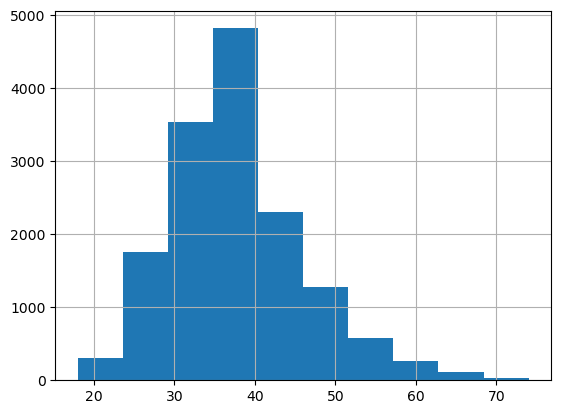

In [25]:
train_val_df.Age.hist()

Я зупинилась на RobustScaler, оскільки вважаю що він краще підходить в цьому випадку ніж StandardScaler, оскільки деякі дані не мають стандартного розподілу, і ніж MinMaxScaler оскільки - Balance має екстримальні значення, Salary має широку варіацію, Age розподіл є скошеним. Коефіцієнти з цим scaler видались мені найстабільнішими.
Хоча модель на 20% тестових даних найкраще перформила з MinMaxScaler.

**Кодування категоріальних ознак**

In [26]:
train_inputs[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

In [27]:
train_inputs['Geography'].unique()

array(['France', 'Germany', 'Spain'], dtype=object)

In [28]:
train_inputs['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [29]:
#encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

Виключила drop='first' з фінального варіанту обробки саме для цього випадку, оскільки це призводило до найгірних результатів на 20% тестових даних і виключення цього параметру ніяк не повпливало на показники оцінки моделі, які ми тут використали. Буду вдячна за пояснення цього моменту, бо сумніваюсь чи це було правильне рішення.

In [30]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [31]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [32]:
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [33]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [34]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [35]:
display(train_inputs[:5])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.330189,France,Male,-0.5,0.00,1.189003,-1.0,1.0,1.0,-0.499891,1.0,0.0,0.0,0.0,1.0
14199,-0.273585,Germany,Female,-0.5,-0.25,1.090681,-1.0,1.0,0.0,0.735531,0.0,1.0,0.0,1.0,0.0
1856,0.169811,France,Female,-1.5,-0.25,0.000000,0.0,1.0,1.0,0.529912,1.0,0.0,0.0,1.0,0.0
3013,0.415094,France,Male,1.1,-0.50,0.000000,0.0,1.0,0.0,-0.051260,1.0,0.0,0.0,0.0,1.0
8266,0.330189,France,Female,-0.2,0.50,0.000000,0.0,1.0,0.0,-0.314648,1.0,0.0,0.0,1.0,0.0


In [36]:
display(val_inputs[:5])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,-1.113208,France,Male,-0.8,1.0,1.089435,-1.0,0.0,0.0,-0.920581,1.0,0.0,0.0,0.0,1.0
1273,-0.594340,Germany,Male,0.4,-0.5,1.127435,-1.0,1.0,0.0,0.723738,0.0,1.0,0.0,0.0,1.0
5414,-0.377358,France,Male,-0.6,0.5,0.000000,-1.0,1.0,1.0,0.362060,1.0,0.0,0.0,0.0,1.0
10923,-0.603774,France,Male,1.9,-0.5,0.000000,2.0,1.0,0.0,-0.280515,1.0,0.0,0.0,0.0,1.0
5835,0.830189,Spain,Female,0.5,0.0,0.000000,-1.0,1.0,1.0,0.790650,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [37]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (11250, 15)
train_targets: (11250,)
val_inputs: (3750, 15)
val_targets: (3750,)


In [38]:
os.makedirs("bank_data/processed", exist_ok=True)

In [39]:
train_inputs.to_parquet("bank_data/processed/train_inputs_3.parquet")
val_inputs.to_parquet("bank_data/processed/val_inputs_3.parquet")

In [40]:
train_targets.to_frame().to_parquet("bank_data/processed/train_targets_3.parquet")
val_targets.to_frame().to_parquet("bank_data/processed/val_targets_3.parquet")

In [41]:
%%time

train_inputs = pd.read_parquet(f'bank_data/processed/train_inputs_3.parquet')
val_inputs = pd.read_parquet(f'bank_data/processed/val_inputs_3.parquet')

CPU times: total: 15.6 ms
Wall time: 27.3 ms


In [42]:
%%time

train_targets = pd.read_parquet(f'bank_data/processed/train_targets_3.parquet')
val_targets = pd.read_parquet(f'bank_data/processed/val_targets_3.parquet')

CPU times: total: 0 ns
Wall time: 7.16 ms


In [43]:
os.listdir("bank_data/processed")

['train_inputs.parquet',
 'train_inputs_2.parquet',
 'train_inputs_3.parquet',
 'train_inputs_4.parquet',
 'train_targets.parquet',
 'train_targets_2.parquet',
 'train_targets_3.parquet',
 'train_targets_4.parquet',
 'val_inputs.parquet',
 'val_inputs_2.parquet',
 'val_inputs_3.parquet',
 'val_inputs_4.parquet',
 'val_targets.parquet',
 'val_targets_2.parquet',
 'val_targets_3.parquet',
 'val_targets_4.parquet']

In [44]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (11250, 15)
train_targets: (11250, 1)
val_inputs: (3750, 15)
val_targets: (3750, 1)


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [45]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [46]:
model = LogisticRegression(solver='liblinear')

In [47]:
model.fit(X_train, train_targets)

C:\Users\mariy\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(solver='liblinear')

In [48]:
model.coef_.round(2)

array([[-0.21,  1.59, -0.03, -0.6 , -1.35, -0.18, -1.27,  0.07, -0.77,
         0.83, -0.86,  0.05, -0.84]])

In [49]:
print(model.coef_.tolist())

[[-0.21234958673750484, 1.5877031349611317, -0.0322309376989303, -0.5959332955521883, -1.3517055815108099, -0.18124922546984626, -1.2688850245869612, 0.0748985778314683, -0.7724484728089417, 0.831772349102289, -0.8580900164988639, 0.045191029946816834, -0.8439571701523572]]


In [50]:
print(model.intercept_)

[-0.79876614]


In [51]:
coef = model.coef_[0]
feature_names = numeric_cols + encoded_cols

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

importance_df

,feature,coef,abs_coef
1,Age,1.587703,1.587703
4,NumOfProducts,-1.351706,1.351706
6,IsActiveMember,-1.268885,1.268885
10,Geography_Spain,-0.858090,0.858090
12,Gender_Male,-0.843957,0.843957
9,Geography_Germany,0.831772,0.831772
8,Geography_France,-0.772448,0.772448
3,Balance,-0.595933,0.595933
0,CreditScore,-0.212350,0.212350
5,HasCrCard,-0.181249,0.181249


In [52]:
train_preds = model.predict(X_train)

In [53]:
train_preds

array([0., 0., 0., ..., 0., 0., 0.])

In [54]:
train_targets

,Exited
8263,0.0
14199,1.0
1856,0.0
3013,0.0
8266,0.0
...,...
9493,0.0
7687,1.0
8143,0.0
11512,0.0


In [55]:
train_probs = model.predict_proba(X_train)

In [56]:
train_probs

array([[0.98407129, 0.01592871],
       [0.51847354, 0.48152646],
       [0.99525555, 0.00474445],
       ...,
       [0.99375301, 0.00624699],
       [0.83653541, 0.16346459],
       [0.94175862, 0.05824138]])

(array([6047., 1754.,  799.,  574.,  425.,  388.,  298.,  300.,  343.,
         322.]),
 array([0.00115389, 0.1004261 , 0.19969832, 0.29897053, 0.39824275,
        0.49751496, 0.59678717, 0.69605939, 0.7953316 , 0.89460382,
        0.99387603]),
 <BarContainer object of 10 artists>)

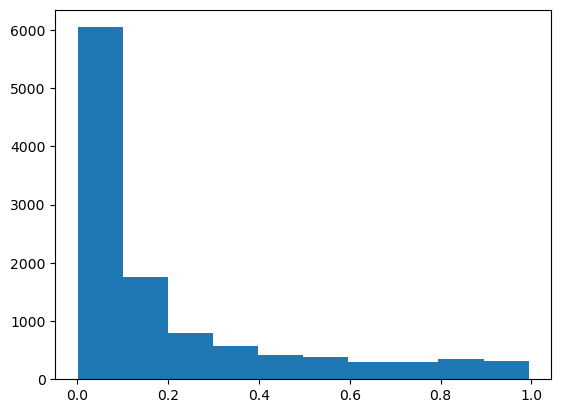

In [57]:
plt.hist(train_probs[:,1])

In [58]:
train_targets.value_counts(normalize=True)

Exited
0.0       0.796533
1.0       0.203467
Name: proportion, dtype: float64

In [59]:
val_preds = model.predict(X_val)

In [60]:
val_preds

array([0., 1., 0., ..., 0., 0., 0.])

In [61]:
val_probs = model.predict_proba(X_val)

(array([1965.,  576.,  303.,  173.,  155.,  122.,  109.,  111.,  128.,
         108.]),
 array([0.00112363, 0.10032981, 0.199536  , 0.29874218, 0.39794837,
        0.49715455, 0.59636074, 0.69556692, 0.7947731 , 0.89397929,
        0.99318547]),
 <BarContainer object of 10 artists>)

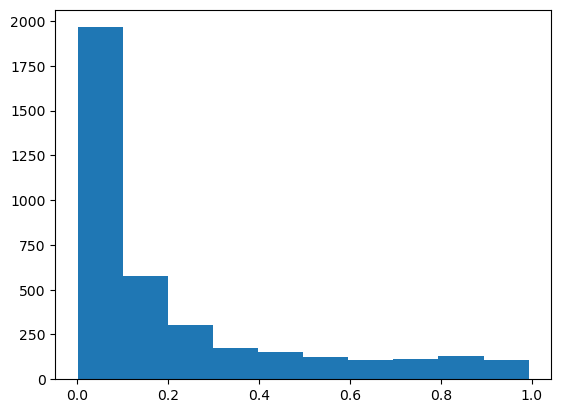

In [62]:
plt.hist(val_probs[:,1])

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [63]:
accuracy_score(train_targets, train_preds)

0.8748444444444444

In [64]:
confusion_matrix(train_targets, train_preds)

array([[8583,  378],
       [1030, 1259]])

In [65]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.48%


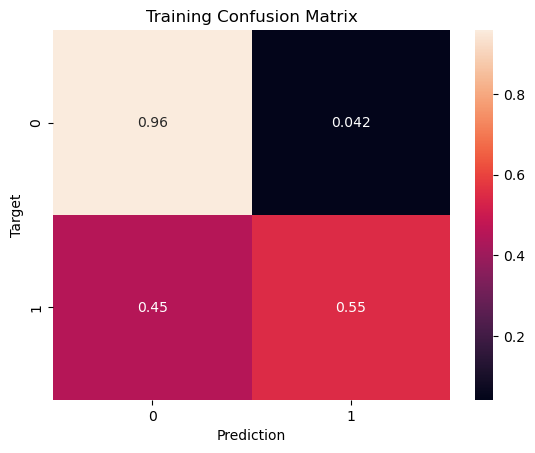

In [66]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 87.12%


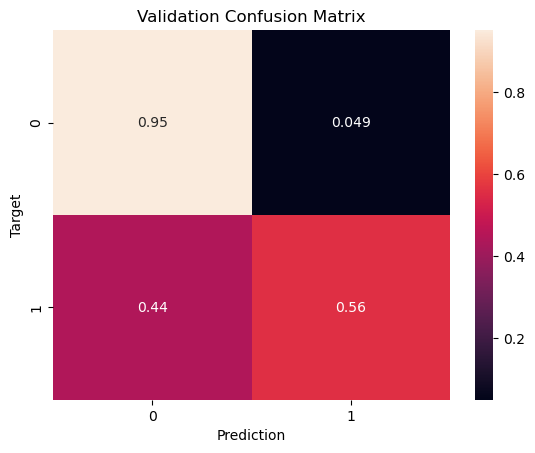

In [67]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [68]:
def random_guess(inputs):
    return np.random.choice([0, 1], len(inputs))

In [69]:
def all_no(inputs):
    return np.full(len(inputs), 0)

In [70]:
accuracy_score(val_targets, random_guess(X_val))

0.4962666666666667

In [71]:
accuracy_score(val_targets, all_no(X_val))

0.7965333333333333

## Обчислення F1 для нашої моделі

In [72]:
f1_train = f1_score(train_targets, train_preds)

In [73]:
f1_train

0.6413652572592969

In [74]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}%")

In [75]:
get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.64%
F1 score Validation: 0.64%


## Побудова ROC Curve та обчислення AUROC для нашої моделі

In [76]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


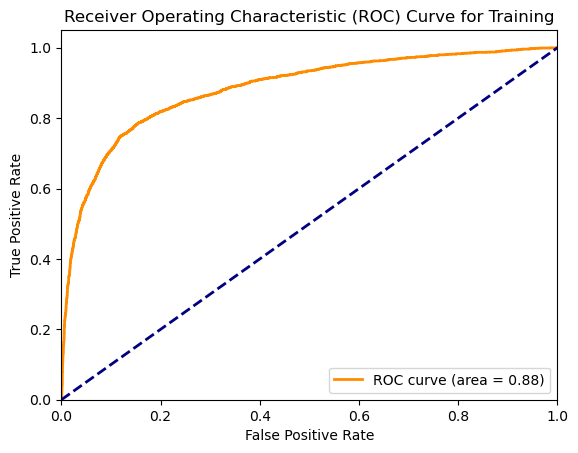

AUROC for Validation: 0.88


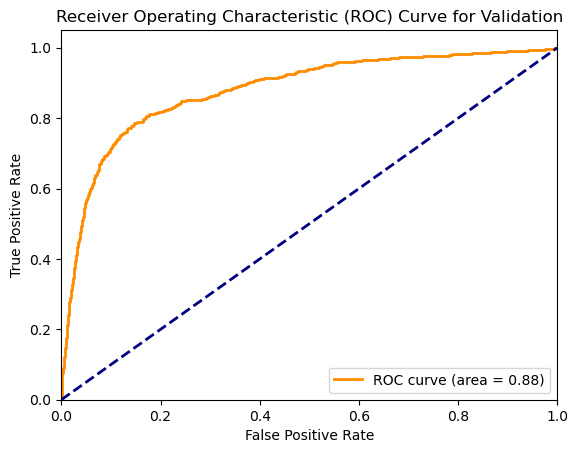

In [77]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

Вигляд ROC Curve є схожим для тренувальних і валідаційних даних:
- крива вище діагоналі → модель краща за випадкову
- крива вигнута вгору, ближче до верхнього лівого кута → модель непогано ловить позитивний клас
- немає різкого «провалу» → модель стабільна на різних порогах

Модель має хорошу чутливість і специфічність.

Значення метрики AUROC співпадають для тренувальних і валідаційних даних. Модель добре узагальнює. 
AUC = 0.88 показує, що модель добре розрізняє класи.

Значення метрики F1 Score півпадають для тренувальних і валідаційних даних. F1 = 0.64 показує, що при поточному порозі 0.5 модель:
- ловить не всіх позитивних клієнтів (recall не ідеальний)
- і не всіх негативних класифікує правильно (precision теж не ідеальний)
  
Це типово для churn‑задач, де позитивний клас (Exited=1) зазвичай більш рідкісний.

Confusion matrix показує, що:
1. Модель чудово розпізнає клас 0 (не пішли)
TN ≈ 95–96%
FP ≈ 4–5%
Це означає:
- модель майже не помиляється, коли каже, що клієнт не піде
- вона дуже добре «бачить» негативний клас
  
Це типово для churn‑задач, де клас 0 домінує.

2. Модель посередньо ловить клас 1 (пішли)
TP ≈ 55–56%
FN ≈ 44–45%
Тобто:
- модель знаходить приблизно половину клієнтів, які підуть
- іншу половину вона пропускає
  
Це теж типово для churn, бо:
- клас 1 більш рідкісний
- поріг 0.5 не оптимальний
- логістична регресія без зміни порогу завжди дає низький recall

Accuracy ≈ 87% виглядає високо, але для цієї задачі модель може просто казати «всі залишаться» і мати доволі високу точність.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [78]:
majority_class = train_targets.mode().iloc[0]
majority_class

Exited    0.0
Name: 0, dtype: float64

In [79]:
train_pred_majority = [majority_class] * len(train_targets)
val_pred_majority = [majority_class] * len(val_targets)

In [80]:
train_acc_majority = accuracy_score(train_targets, train_pred_majority)
val_acc_majority = accuracy_score(val_targets, val_pred_majority)

In [81]:
train_acc_majority, val_acc_majority

(0.7965333333333333, 0.7965333333333333)

Accuracy натренованої моделі - 87%, Accuracy моделі яка передбачає завжди мажоритарний клас - 80%. Вдалось покращити Accuracy тільки на 7% при порозі чутливості 0.5. На цьому етапі як підсумок я вважаю, що модель виглядає задовільною, але я підозрюю, що можна ще покращити якість самої моделі навіть для заданого порогу чутливості, якщо згенерувати додаткові ознаки (протестую в наступному домашньому).

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [82]:
work_log_model = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [83]:
joblib.dump(work_log_model, 'work_log_model_3.joblib')

['work_log_model_3.joblib']

In [84]:
work_log_model_2 = joblib.load('work_log_model_3.joblib')

In [85]:
train_preds_2 = work_log_model_2['model'].predict(X_train)
accuracy_score(train_targets, train_preds_2)

0.8748444444444444

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [86]:
binary_columns = ['HasCrCard', 'IsActiveMember']

In [87]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(model, scaler, encoder, numeric_cols, binary_columns, categorical_cols, input_df: pd.DataFrame):

    df = input_df.copy()

    # Convert ID columns to string
    for col in ["Id", "CustomerId"]:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # Drop unwanted columns BEFORE scaling
    drop_cols = ["Id", "CustomerId", "Surname"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
    

    # Scale numeric
    X_num = scaler.transform(df[numeric_cols])

    # Encode categorical
    X_cat = encoder.transform(df[categorical_cols])

    # Binary columns (0/1)
    X_bin = df[binary_columns].values

    # Combine
    X_input = np.hstack([X_num, X_cat, X_bin])

    # Predict
    prob = model.predict_proba(X_input)[:, 1]

    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [89]:
test_raw_df = pd.read_csv("bank_data/test.csv")

In [90]:
test_raw_df['Exited'] = predict_raw_df(
    model,
    scaler,
    encoder,
    num_cols_to_scale,
    binary_columns,
    categorical_cols,
    test_raw_df
)

In [91]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.055269
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.045289
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.106792
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.308119
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.098779


(array([4498., 1627.,  874.,  598.,  477.,  402.,  330.,  350.,  394.,
         450.]),
 array([6.43379267e-08, 9.96342612e-02, 1.99268458e-01, 2.98902655e-01,
        3.98536852e-01, 4.98171049e-01, 5.97805246e-01, 6.97439443e-01,
        7.97073639e-01, 8.96707836e-01, 9.96342033e-01]),
 <BarContainer object of 10 artists>)

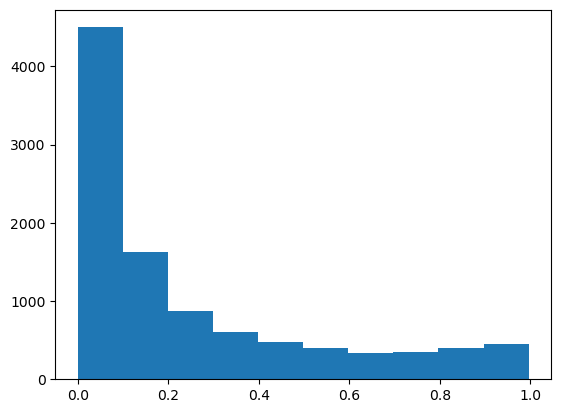

In [92]:
test_probs = predict_raw_df(
    model,
    scaler,
    encoder,
    num_cols_to_scale,
    binary_columns,
    categorical_cols,
    test_raw_df
)

plt.hist(test_probs)

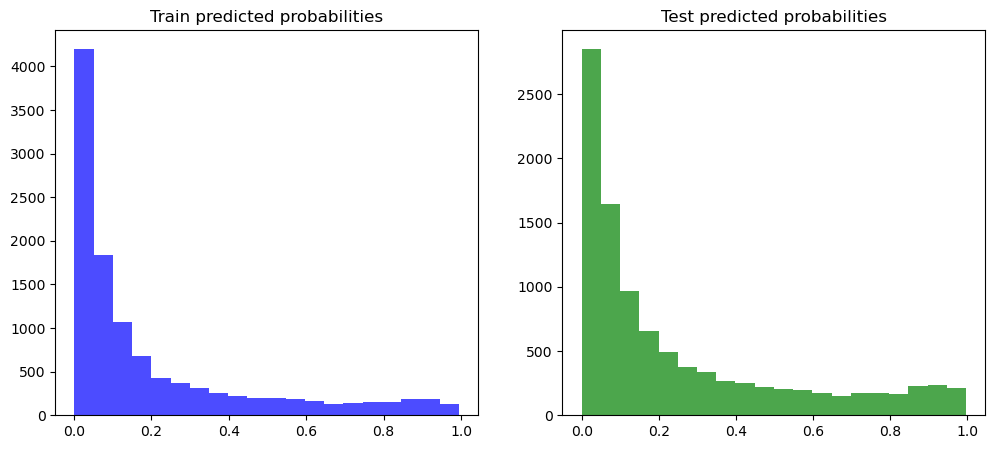

In [93]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train_probs[:,1], bins=20, color='blue', alpha=0.7)
plt.title("Train predicted probabilities")

plt.subplot(1,2,2)
plt.hist(test_probs, bins=20, color='green', alpha=0.7)
plt.title("Test predicted probabilities")

plt.show()

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [94]:
submission = pd.read_csv("bank_data/sample_submission.csv")

In [95]:
submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [96]:
final = submission.merge(test_raw_df[['id', 'Exited']], on='id', how='left')

In [97]:
final.head()

,id,Exited_x,Exited_y
0,15000,0.5,0.055269
1,15001,0.5,0.045289
2,15002,0.5,0.106792
3,15003,0.5,0.308119
4,15004,0.5,0.098779


In [98]:
final['Exited'] = final['Exited_y']

In [99]:
final = final[['id', 'Exited']]

In [100]:
print(final.head())

      id    Exited
0  15000  0.055269
1  15001  0.045289
2  15002  0.106792
3  15003  0.308119
4  15004  0.098779


In [101]:
final.to_csv("bank_data/submission_log_reg_3.csv", index=False)

Як підсумок, в цьому домашньому завданні я протестувала 4 моделі, з різним типом маштабування, з маштабуванням всіх числових колонок та тільки тих які не були в діапазоні 0-1, з кількістю features, які йдуть в модель. Цікаво було саме подивитись, як змінюватимуться коефіцієнти моделі, що саме впливає на їх стабільність і який результат на оцінці тестувальних даних. Остаточно я залишила модель, з якою отримала середній результут на тесті. Оскільки вважаю її найбільш стабільною. 